In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Approach Overview
This solution follows a **dual-stream modeling strategy**, combining acoustic and linguistic signals to predict grammar scores more reliably.

### Audio Stream
Raw `.wav` files are processed using `librosa` to extract paralinguistic features such as:

* Speaking rate
* Pause frequency and duration
* Pitch-related features
* Energy dynamics

These features help capture delivery patterns that may correlate with grammatical control and sentence construction stability.

### Text Stream
Each audio file is transcribed using **Whisper (medium variant)** to ensure high transcription accuracy, since grammar evaluation is highly sensitive to transcription quality.

From the transcript, linguistic features are extracted using:

* **LanguageTool** for explicit grammatical error detection
* **spaCy** for syntactic and structural analysis
* **textstat** for readability and complexity metrics

This stream captures structural grammar signals beyond surface-level token statistics.

### Feature Fusion & Modeling
Both feature streams are concatenated into a unified feature vector.
The final model pipeline includes:

* A **LightGBM regressor** as the primary model
* 5-fold cross-validation to ensure robust generalization
* A **Ridge regression model** ensembled with LightGBM to reduce variance and improve stability

### Key Design Decisions
* **Whisper (medium)** was selected to balance transcription accuracy and computational efficiency, given the sensitivity of grammar scoring to ASR errors.
* **LanguageTool** was used for direct grammatical error detection rather than relying solely on POS-based heuristics.
* Transcriptions were cached to CSV to avoid redundant inference and improve reproducibility.
* Final predictions were clipped to the valid MOS range ([1, 5]) to ensure score consistency with rubric constraints.

In [5]:
import os
import warnings
from collections import Counter

import nltk
import language_tool_python
import spacy
import textstat

import lightgbm as lgb
import optuna
import shap
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
# optuna.logging.set_verbosity(optuna.logging.WARNING)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

SEED = 42
np.random.seed(SEED)

In [27]:
from pathlib import Path

AUDIO_DIR   = Path('/kaggle/input/competitions/shl-audio-scoring-challenge/dataset')
TRAIN_CSV   = AUDIO_DIR / 'csvs' / 'train.csv'
TEST_CSV    = AUDIO_DIR / 'csvs' / 'test.csv'
TRAIN_AUDIO = AUDIO_DIR / 'audios' / 'train'
TEST_AUDIO  = AUDIO_DIR / 'audios' / 'test'
OUTPUT_DIR  = Path('/kaggle/working')

TRAIN_CACHE = OUTPUT_DIR / "train_transcripts.csv"
TEST_CACHE  = OUTPUT_DIR / "test_transcripts.csv"

print(f"   Train audio dir exists: {TRAIN_AUDIO.exists()}")
print(f"   Test audio dir exists:  {TEST_AUDIO.exists()}")

   Train audio dir exists: True
   Test audio dir exists:  True


In [7]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print()
print(train_df.head())

Train shape: (409, 2)
Test shape:  (197, 1)

    filename  label
0  audio_173    3.0
1  audio_138    3.0
2  audio_127    2.0
3   audio_95    2.0
4   audio_73    3.5


In [8]:
print("Label Distribution:")
print(train_df['label'].value_counts().sort_index())
print(f"\nMean: {train_df['label'].mean():.2f}")
print(f"Std:  {train_df['label'].std():.2f}")
print(f"Min:  {train_df['label'].min()}")
print(f"Max:  {train_df['label'].max()}")

Label Distribution:
label
1.0      1
1.5      1
2.0     90
2.5     72
3.0    154
3.5     46
4.0     15
4.5     10
5.0     20
Name: count, dtype: int64

Mean: 2.91
Std:  0.77
Min:  1.0
Max:  5.0


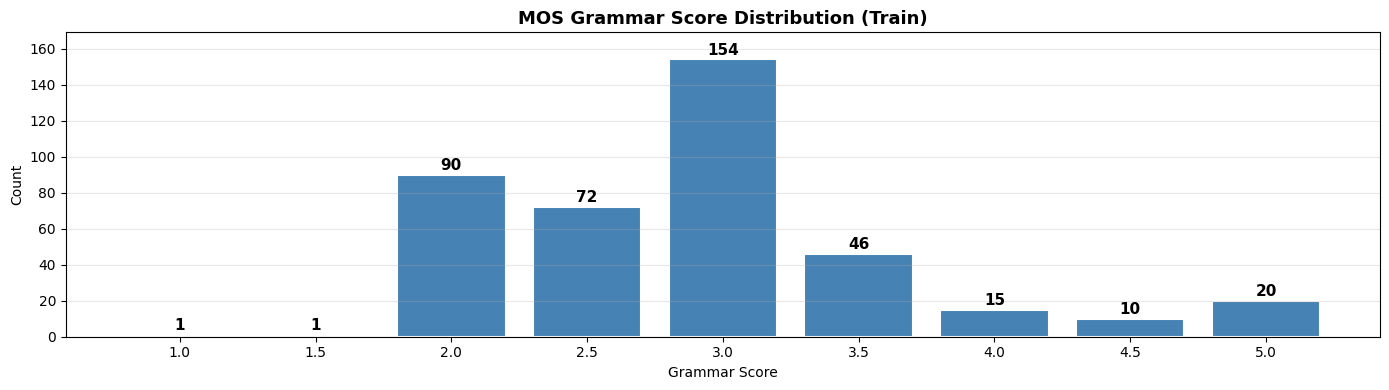

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))

counts = train_df['label'].value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(count),
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('MOS Grammar Score Distribution (Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Grammar Score')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() + 15)
ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
import librosa
import whisper

whisper_model = whisper.load_model("medium", device="cuda")
print("Whisper medium loaded on GPU.")

100%|█████████████████████████████████████| 1.42G/1.42G [00:19<00:00, 79.9MiB/s]


Whisper medium loaded on GPU.


In [11]:
def transcribe_audio(audio_path: str) -> dict:
    try:
        result = whisper_model.transcribe(
            str(audio_path),
            language='en',
            fp16=True,
            verbose=False
        )
        # Duration from audio
        y, sr = librosa.load(str(audio_path), sr=None)
        duration = len(y) / sr
        return {'text': result['text'].strip(), 'duration': duration}
    except Exception as e:
        print(f"Error transcribing {audio_path}: {e}")
        return {'text': '', 'duration': 0.0}


def transcribe_dataset(df: pd.DataFrame, audio_dir: Path, cache_path: Path) -> pd.DataFrame:
    if cache_path.exists():
        print(f"Loading cached transcriptions from {cache_path.name}")
        return pd.read_csv(cache_path)

    print(f"Transcribing {len(df)} files with Whisper medium...")
    records = []
    print(df['filename'].head())
    for i, row in df.iterrows():
        matches = list(audio_dir.glob(row['filename'] + '.*'))
        fpath = matches[0] if matches else audio_dir / row['filename']
        result = transcribe_audio(fpath)
        rec = {'filename': row['filename'], 'transcript': result['text'], 'duration': result['duration']}
        if 'label' in row:
            rec['label'] = row['label']
        records.append(rec)
        if (i + 1) % 50 == 0:
            print(f"   ... {i+1}/{len(df)} done")

    result_df = pd.DataFrame(records)
    result_df.to_csv(cache_path, index=False)
    print(f"Transcriptions saved to {cache_path.name}")
    return result_df


print("Transcription functions defined.")

Transcription functions defined.


In [28]:
train_transcripts = transcribe_dataset(train_df, TRAIN_AUDIO, TRAIN_CACHE)
test_transcripts  = transcribe_dataset(test_df,  TEST_AUDIO,  TEST_CACHE)

print(f"\nTrain transcripts shape: {train_transcripts.shape}")
print(f"Test transcripts shape:  {test_transcripts.shape}")

Loading cached transcriptions from train_transcripts.csv
Loading cached transcriptions from test_transcripts.csv

Train transcripts shape: (409, 4)
Test transcripts shape:  (197, 3)


In [13]:
def extract_audio_features(audio_path: str, transcript: str, duration: float) -> dict:
    """
    Extract paralinguistic features directly from the WAV file.
    
    Features:
    - speaking_rate: words per second (fluency proxy)
    - silence_ratio: fraction of audio that is silence (hesitation proxy)
    - pitch_mean, pitch_std: F0 statistics (confidence/prosody proxy)
    - rms_mean, rms_std: energy statistics (volume consistency)
    - zcr_mean: zero crossing rate (noise/clarity proxy)
    - spectral_centroid_mean: brightness of voice
    """
    feats = {}
    try:
        y, sr = librosa.load(str(audio_path), sr=16000)

        # Speaking rate
        word_count = len(transcript.split()) if transcript else 0
        feats['speaking_rate'] = word_count / duration if duration > 0 else 0.0

        # Silence ratio
        rms_frames = librosa.feature.rms(y=y, frame_length=512, hop_length=256)[0]
        silence_threshold = np.percentile(rms_frames, 20)  # bottom 20% = silence
        feats['silence_ratio'] = float(np.mean(rms_frames < silence_threshold))
        feats['rms_mean'] = float(np.mean(rms_frames))
        feats['rms_std']  = float(np.std(rms_frames))

        # Pitch (F0)
        f0, voiced_flag, _ = librosa.pyin(y, fmin=librosa.note_to_hz('C2'),
                                           fmax=librosa.note_to_hz('C7'), sr=sr)
        voiced_f0 = f0[voiced_flag] if voiced_flag is not None else np.array([])
        feats['pitch_mean'] = float(np.mean(voiced_f0)) if len(voiced_f0) > 0 else 0.0
        feats['pitch_std']  = float(np.std(voiced_f0))  if len(voiced_f0) > 0 else 0.0
        feats['voiced_ratio'] = float(np.mean(voiced_flag)) if voiced_flag is not None else 0.0

        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y, hop_length=256)[0]
        feats['zcr_mean'] = float(np.mean(zcr))

        # Spectral centroid
        sc = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=256)[0]
        feats['spectral_centroid_mean'] = float(np.mean(sc))
        feats['spectral_centroid_std']  = float(np.std(sc))

        # MFCC statistics (top 5 coefficients)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=256)
        for j in range(5):
            feats[f'mfcc_{j}_mean'] = float(np.mean(mfcc[j]))
            feats[f'mfcc_{j}_std']  = float(np.std(mfcc[j]))

    except Exception as e:
        print(f"Audio feature error for {audio_path}: {e}")
        # Return zero-filled fallback
        feats = {k: 0.0 for k in [
            'speaking_rate','silence_ratio','rms_mean','rms_std',
            'pitch_mean','pitch_std','voiced_ratio','zcr_mean',
            'spectral_centroid_mean','spectral_centroid_std'
        ] + [f'mfcc_{j}_{s}' for j in range(5) for s in ['mean','std']]}

    return feats

print("Audio feature extractor defined.")

Audio feature extractor defined.


In [14]:
nlp  = spacy.load('en_core_web_sm')
tool = language_tool_python.LanguageTool('en-US')

FILLER_WORDS = {'uh', 'um', 'er', 'ah', 'hmm', 'erm', 'uhh', 'umm'}

print("spaCy and LanguageTool loaded.")

spaCy and LanguageTool loaded.


In [15]:
def extract_text_features(transcript: str) -> dict:
    """
    Extract linguistic and grammar features from the transcript.

    Categories:
    - Grammar errors (via LanguageTool): total count, density, by category
    - Fluency: filler word ratio, repetition ratio
    - Vocabulary: type-token ratio, avg word length
    - Sentence structure: avg length, depth (spaCy dependency tree)
    - Readability: Flesch score
    """
    feats = {}

    if not isinstance(transcript, str) or len(transcript.strip()) < 5:
        return {k: 0.0 for k in [
            'grammar_errors','error_density','grammar_error_count',
            'style_error_count','typo_error_count',
            'filler_ratio','repetition_ratio','ttr',
            'avg_word_length','avg_sentence_length',
            'avg_dep_depth','num_sentences','flesch_score'
        ]}

    words = transcript.lower().split()
    word_count = len(words) if words else 1

    # LanguageTool grammar errors
    matches = tool.check(transcript)
    feats['grammar_errors']      = len(matches)
    feats['error_density']       = len(matches) / word_count

    # Break down by error category
    grammar_cats = {'GRAMMAR': 0, 'STYLE': 0, 'TYPOS': 0, 'OTHER': 0}
    for m in matches:
        cat = m.category if hasattr(m, 'category') else 'OTHER'
        if cat in grammar_cats:
            grammar_cats[cat] += 1
        else:
            grammar_cats['OTHER'] += 1
    feats['grammar_error_count'] = grammar_cats['GRAMMAR']
    feats['style_error_count']   = grammar_cats['STYLE']
    feats['typo_error_count']    = grammar_cats['TYPOS']

    # Filler words
    filler_count = sum(1 for w in words if w in FILLER_WORDS)
    feats['filler_ratio'] = filler_count / word_count

    # Repetition
    counts = Counter(words)
    feats['repetition_ratio'] = sum(v for v in counts.values() if v > 1) / word_count

    # Vocabulary diversity (Type-Token Ratio)
    unique_words = len(set(words))
    feats['ttr'] = unique_words / word_count

    # Avg word length
    feats['avg_word_length'] = np.mean([len(w) for w in words]) if words else 0.0

    # Sentence-level features via spaCy
    doc = nlp(transcript)
    sentences = list(doc.sents)
    num_sentences = len(sentences) if sentences else 1
    feats['num_sentences'] = num_sentences
    feats['avg_sentence_length'] = word_count / num_sentences

    # Dependency tree depth — proxy for sentence complexity
    def dep_depth(token):
        depth = 0
        current = token
        while current.head != current:
            current = current.head
            depth += 1
        return depth

    depths = [dep_depth(t) for t in doc]
    feats['avg_dep_depth'] = float(np.mean(depths)) if depths else 0.0

    # Readability
    try:
        feats['flesch_score'] = textstat.flesch_reading_ease(transcript)
    except:
        feats['flesch_score'] = 50.0  # neutral fallback

    return feats

print("Text feature extractor defined.")

Text feature extractor defined.


In [16]:
def build_features(transcripts_df: pd.DataFrame, audio_dir: Path, cache_path: Path) -> pd.DataFrame:
    """
    Build the full feature matrix by combining audio and text features.
    Uses cache if available.
    """
    if cache_path.exists():
        print(f"Loading cached features from {cache_path.name}")
        return pd.read_csv(cache_path)

    print(f"Extracting features for {len(transcripts_df)} samples...")
    all_feats = []

    for i, row in transcripts_df.iterrows():
        matches = list(audio_dir.glob(row['filename'] + '.*'))
        fpath = matches[0] if matches else audio_dir / row['filename']
        
        # Audio features
        audio_feats = extract_audio_features(str(fpath), row.get('transcript', ''), row.get('duration', 60.0))
        
        # Text features
        text_feats = extract_text_features(row.get('transcript', ''))
        
        # Merge
        combined = {'filename': row['filename']}
        combined.update(audio_feats)
        combined.update(text_feats)
        if 'label' in row:
            combined['label'] = row['label']
        all_feats.append(combined)

        if (i + 1) % 50 == 0:
            print(f"   ... {i+1}/{len(transcripts_df)} done")

    feat_df = pd.DataFrame(all_feats)
    feat_df.to_csv(cache_path, index=False)
    print(f"Features saved to {cache_path.name} — shape: {feat_df.shape}")
    return feat_df


print("Feature builder defined.")

Feature builder defined.


In [17]:
train_feats = build_features(train_transcripts, TRAIN_AUDIO, OUTPUT_DIR / 'train_features.csv')
test_feats  = build_features(test_transcripts,  TEST_AUDIO,  OUTPUT_DIR / 'test_features.csv')

print(f"\nTrain features shape: {train_feats.shape}")
print(f"Test features shape:  {test_feats.shape}")
print(f"\nFeature columns:")
feat_cols = [c for c in train_feats.columns if c not in ['filename', 'label']]
print(feat_cols)

Extracting features for 409 samples...
   ... 50/409 done
   ... 100/409 done
   ... 150/409 done
   ... 200/409 done
   ... 250/409 done
   ... 300/409 done
   ... 350/409 done
   ... 400/409 done
Features saved to train_features.csv — shape: (409, 35)
Extracting features for 197 samples...
   ... 50/197 done
   ... 100/197 done
   ... 150/197 done
Features saved to test_features.csv — shape: (197, 34)

Train features shape: (409, 35)
Test features shape:  (197, 34)

Feature columns:
['speaking_rate', 'silence_ratio', 'rms_mean', 'rms_std', 'pitch_mean', 'pitch_std', 'voiced_ratio', 'zcr_mean', 'spectral_centroid_mean', 'spectral_centroid_std', 'mfcc_0_mean', 'mfcc_0_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'grammar_errors', 'error_density', 'grammar_error_count', 'style_error_count', 'typo_error_count', 'filler_ratio', 'repetition_ratio', 'ttr', 'avg_word_length', 'num_sentences', 'avg_sentence_length', 

In [18]:
# Prepare X, y
feat_cols = [c for c in train_feats.columns if c not in ['filename', 'label']]

X_train = train_feats[feat_cols].fillna(0).values
y_train = train_feats['label'].values
X_test  = test_feats[feat_cols].fillna(0).values

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (409, 33), y_train: (409,)
X_test:  (197, 33)


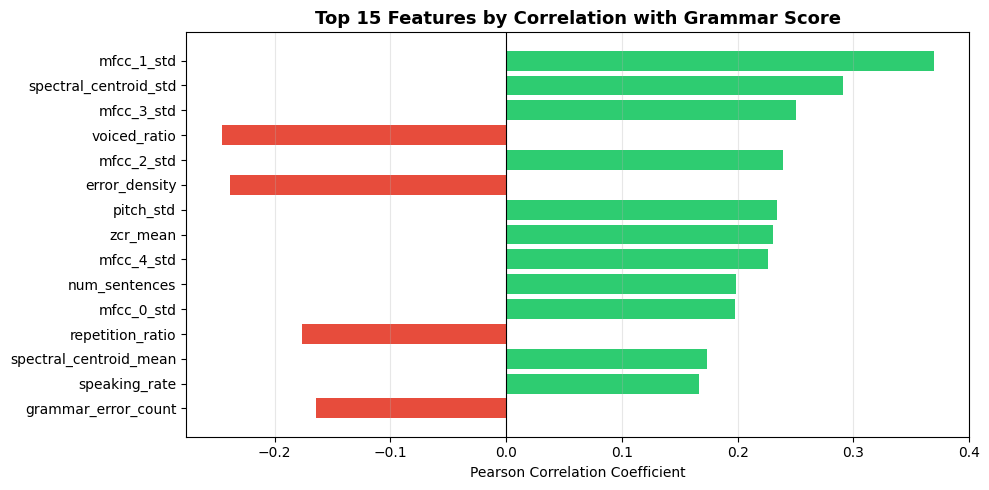

In [19]:
# Top features correlated with grammar score
corr_df = train_feats[feat_cols + ['label']].corr()['label'].drop('label')
top_corr = corr_df.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if corr_df[c] > 0 else '#e74c3c' for c in top_corr.index]
plt.barh(top_corr.index[::-1], corr_df[top_corr.index[::-1]], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Features by Correlation with Grammar Score', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'objective':         'regression',
        'metric':            'rmse',
        'random_state':      SEED,
        'verbosity':         -1,
        'n_jobs':            -1,
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, val_idx in kf.split(X_train):
        Xtr, Xval = X_train[tr_idx], X_train[val_idx]
        ytr, yval = y_train[tr_idx], y_train[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(Xtr, ytr, eval_set=[(Xval, yval)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        preds = model.predict(Xval)
        preds = np.clip(preds, 1, 5)
        scores.append(np.sqrt(mean_squared_error(yval, preds)))
    return np.mean(scores)


print("Running Optuna hyperparameter search (30 trials)...")
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
best_params.update({'objective': 'regression', 'metric': 'rmse', 'random_state': SEED, 'verbosity': -1, 'n_jobs': -1})
print(f"\n Best CV RMSE: {study.best_value:.4f}")
print(f"   Best params: {best_params}")

[I 2026-03-03 06:37:52,557] A new study created in memory with name: no-name-66253331-1661-470d-8998-f0b958b30ad0


Running Optuna hyperparameter search (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-03 06:37:52,840] Trial 0 finished with value: 0.6759529934648123 and parameters: {'n_estimators': 687, 'learning_rate': 0.0862735828664018, 'max_depth': 8, 'num_leaves': 82, 'min_child_samples': 12, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 2.1423021757741068, 'reg_lambda': 0.10129197956845731}. Best is trial 0 with value: 0.6759529934648123.
[I 2026-03-03 06:37:54,526] Trial 1 finished with value: 0.6712043147421722 and parameters: {'n_estimators': 1121, 'learning_rate': 0.005318033256270142, 'max_depth': 10, 'num_leaves': 109, 'min_child_samples': 14, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 0.0033205591037519565, 'reg_lambda': 0.042051564509138675}. Best is trial 1 with value: 0.6712043147421722.
[I 2026-03-03 06:37:55,285] Trial 2 finished with value: 0.6678589414357572 and parameters: {'n_estimators': 761, 'learning_rate': 0.011963764382790322, 'max_depth': 7, 'num_leaves': 30, 'min

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds_lgbm  = np.zeros(len(y_train))
test_preds_lgbm = np.zeros(len(X_test))
fold_rmses = []

print("Training LightGBM with 5-Fold CV...\n")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    Xtr, Xval = X_train[tr_idx], X_train[val_idx]
    ytr, yval = y_train[tr_idx], y_train[val_idx]

    model_lgbm = lgb.LGBMRegressor(**best_params)
    model_lgbm.fit(
        Xtr, ytr,
        eval_set=[(Xval, yval)],
        callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(-1)]
    )

    val_preds = np.clip(model_lgbm.predict(Xval), 1, 5)
    oof_preds_lgbm[val_idx] = val_preds
    test_preds_lgbm += np.clip(model_lgbm.predict(X_test), 1, 5) / 5

    rmse = np.sqrt(mean_squared_error(yval, val_preds))
    fold_rmses.append(rmse)
    print(f"   Fold {fold+1} RMSE: {rmse:.4f}")

lgbm_cv_rmse = np.sqrt(mean_squared_error(y_train, oof_preds_lgbm))
print(f"\n LightGBM OOF RMSE: {lgbm_cv_rmse:.4f} ± {np.std(fold_rmses):.4f}")

Training LightGBM with 5-Fold CV...

   Fold 1 RMSE: 0.6409
   Fold 2 RMSE: 0.6111
   Fold 3 RMSE: 0.6921
   Fold 4 RMSE: 0.6235
   Fold 5 RMSE: 0.7392

 LightGBM OOF RMSE: 0.6629 ± 0.0477


In [22]:
oof_preds_ridge  = np.zeros(len(y_train))
test_preds_ridge = np.zeros(len(X_test))

scaler = StandardScaler()

print("Training Ridge Regression with 5-Fold CV...\n")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    Xtr, Xval = X_train[tr_idx], X_train[val_idx]
    ytr, yval = y_train[tr_idx], y_train[val_idx]

    Xtr_s  = scaler.fit_transform(Xtr)
    Xval_s = scaler.transform(Xval)
    Xtest_s = scaler.transform(X_test)

    ridge = Ridge(alpha=10.0)
    ridge.fit(Xtr_s, ytr)

    val_preds = np.clip(ridge.predict(Xval_s), 1, 5)
    oof_preds_ridge[val_idx] = val_preds
    test_preds_ridge += np.clip(ridge.predict(Xtest_s), 1, 5) / 5

    rmse = np.sqrt(mean_squared_error(yval, val_preds))
    print(f"   Fold {fold+1} RMSE: {rmse:.4f}")

ridge_cv_rmse = np.sqrt(mean_squared_error(y_train, oof_preds_ridge))
print(f"\n Ridge OOF RMSE: {ridge_cv_rmse:.4f}")

Training Ridge Regression with 5-Fold CV...

   Fold 1 RMSE: 0.6643
   Fold 2 RMSE: 0.6835
   Fold 3 RMSE: 0.6987
   Fold 4 RMSE: 0.6367
   Fold 5 RMSE: 0.8171

 Ridge OOF RMSE: 0.7025


In [23]:
# Weight by inverse RMSE (better model gets more weight)
w_lgbm  = 1 / lgbm_cv_rmse
w_ridge = 1 / ridge_cv_rmse
total_w = w_lgbm + w_ridge

lgbm_w  = w_lgbm  / total_w
ridge_w = w_ridge / total_w

oof_ensemble  = lgbm_w * oof_preds_lgbm  + ridge_w * oof_preds_ridge
test_ensemble = lgbm_w * test_preds_lgbm + ridge_w * test_preds_ridge

oof_ensemble  = np.clip(oof_ensemble,  1, 5)
test_ensemble = np.clip(test_ensemble, 1, 5)

ensemble_rmse = np.sqrt(mean_squared_error(y_train, oof_ensemble))

print(f"Model Weights  — LightGBM: {lgbm_w:.3f} | Ridge: {ridge_w:.3f}")
print(f"LightGBM RMSE: {lgbm_cv_rmse:.4f}")
print(f"Ridge RMSE:    {ridge_cv_rmse:.4f}")
print(f"\n Ensemble OOF RMSE (Training Data): {ensemble_rmse:.4f}")

Model Weights  — LightGBM: 0.515 | Ridge: 0.485
LightGBM RMSE: 0.6629
Ridge RMSE:    0.7025

 Ensemble OOF RMSE (Training Data): 0.6668


In [24]:
submission = pd.DataFrame({
    'filename': test_feats['filename'],
    'label':    np.round(test_ensemble, 2)
})

submission_path = OUTPUT_DIR / 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f" submission.csv saved — shape: {submission.shape}")
print(f"   Predicted score range: [{submission['label'].min():.2f}, {submission['label'].max():.2f}]")
print(f"   Predicted score mean:  {submission['label'].mean():.2f}")
print()
print(submission.head(10))

 submission.csv saved — shape: (197, 2)
   Predicted score range: [2.01, 4.16]
   Predicted score mean:  3.03

      filename  label
0    audio_141   2.57
1    audio_114   3.00
2     audio_17   2.57
3     audio_76   3.42
4    audio_156   2.94
5   audio_13_1   3.14
6     audio_70   2.10
7     audio_56   2.85
8     audio_19   3.26
9  audio_158_1   3.13


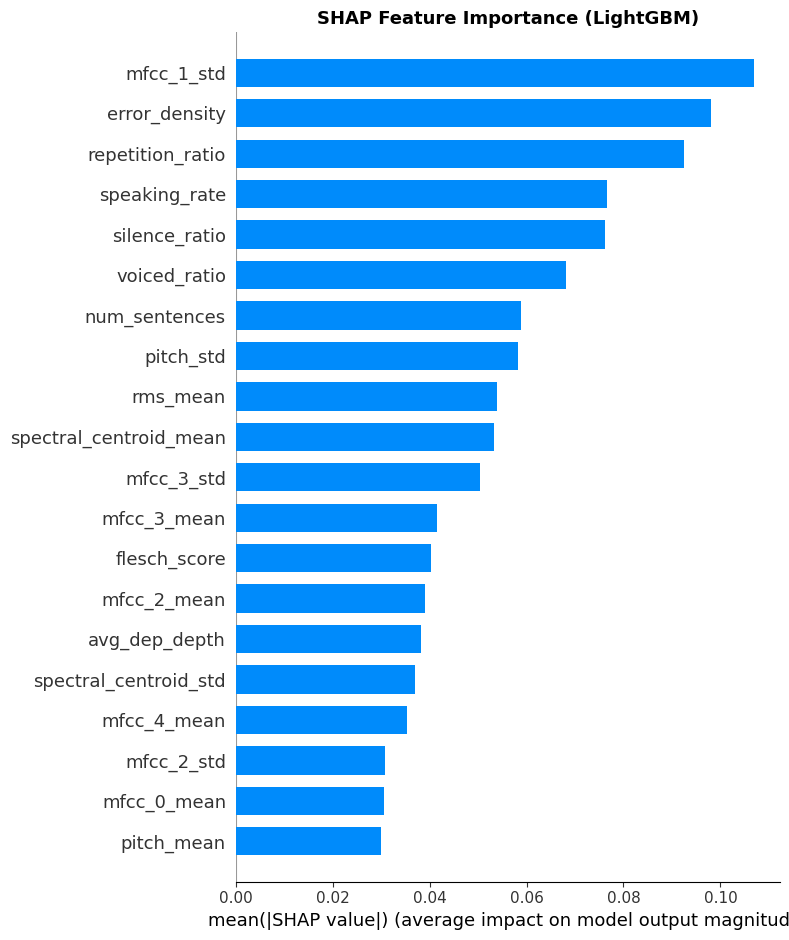

In [25]:
# Train a final LightGBM on all training data for SHAP analysis
final_lgbm = lgb.LGBMRegressor(**best_params)
final_lgbm.fit(X_train, y_train, callbacks=[lgb.log_evaluation(-1)])

explainer   = shap.TreeExplainer(final_lgbm)
shap_values = explainer.shap_values(X_train)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_train,
    feature_names=feat_cols,
    plot_type='bar',
    show=False,
    max_display=20
)
plt.title('SHAP Feature Importance (LightGBM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

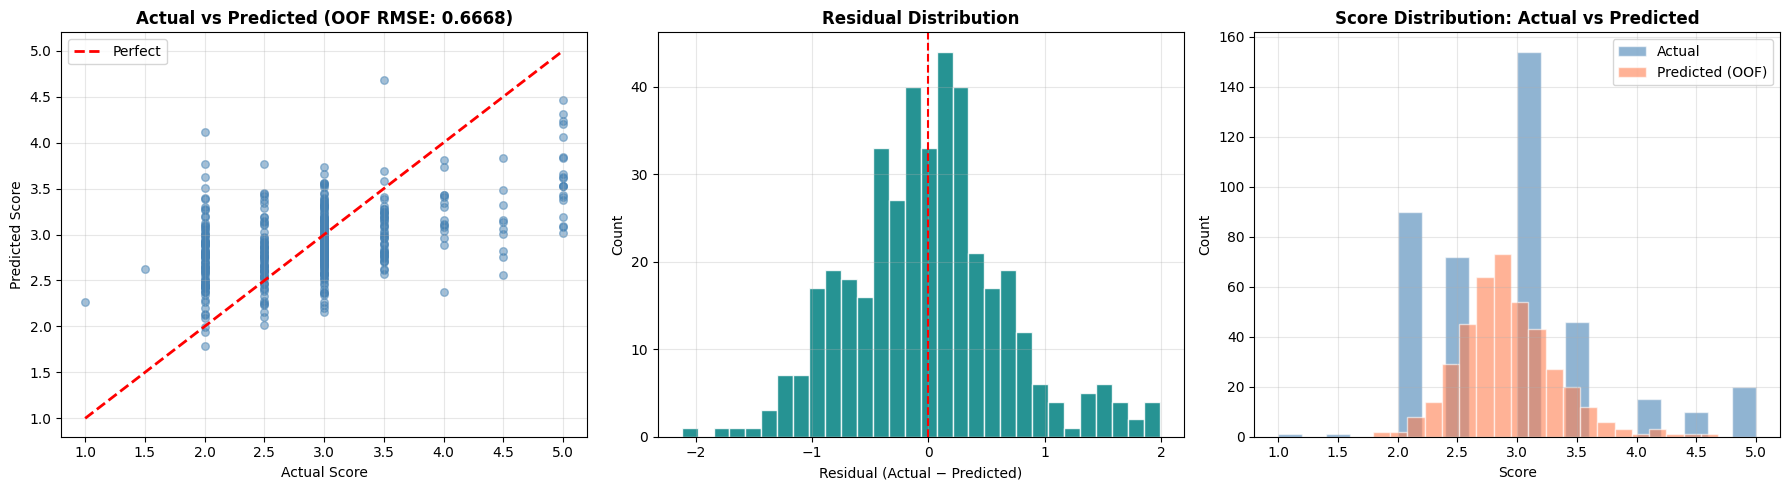

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted scatter
ax = axes[0]
ax.scatter(y_train, oof_ensemble, alpha=0.5, color='steelblue', s=30)
ax.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect')
ax.set_xlabel('Actual Score')
ax.set_ylabel('Predicted Score')
ax.set_title(f'Actual vs Predicted (OOF RMSE: {ensemble_rmse:.4f})', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Residual distribution
ax = axes[1]
residuals = y_train - oof_ensemble
ax.hist(residuals, bins=30, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Residual (Actual − Predicted)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution', fontweight='bold')
ax.grid(alpha=0.3)

# Predicted vs Actual distributions
ax = axes[2]
ax.hist(y_train, bins=20, alpha=0.6, color='steelblue', label='Actual', edgecolor='white')
ax.hist(oof_ensemble, bins=20, alpha=0.6, color='coral', label='Predicted (OOF)', edgecolor='white')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.set_title('Score Distribution: Actual vs Predicted', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Final Report

### Problem Statement

The goal was to build a Grammar Scoring Engine that takes a 45–60 second WAV audio sample and predicts a continuous MOS Likert grammar score between 1 and 5. The idea is to approximate human scoring by capturing both grammatical accuracy and how the speech is delivered.

### Pipeline Architecture
The system follows a two-stream approach — one for audio features and one for text features.

1. Audio Stream

Using librosa, the raw audio is processed to extract:
Speaking rate
Silence ratio
Pitch (mean and std)
Energy and ZCR
MFCC summary statistics

In total, around 20 acoustic features are generated. These mainly capture fluency and prosodic control.

2. Text Stream
The audio is transcribed using Whisper (medium) to maintain good transcription quality since grammar scoring is highly dependent on transcript accuracy.

From the transcript, we extract:
Grammar error count and density using LanguageTool
Dependency depth and sentence structure features using spaCy
Readability metrics from textstat
Custom features like filler ratio, repetition and type-token ratio
This gives around 13 linguistic features.

### Feature Fusion & Modeling

Both feature sets are combined into a 33-dimensional feature vector.
Two models were trained using 5-fold cross-validation:
LightGBM (main model)
Ridge Regression (as a regularized baseline)
Final predictions are generated using an inverse-RMSE weighted ensemble.
Outputs are clipped to the valid MOS range of [1, 5].

### Preprocessing Steps

Audio resampled to 16kHz for consistency.
Whisper transcriptions cached to avoid re-running inference.
Silence detected using RMS energy below 20th percentile.
Missing values handled using fillna(0).
Predictions clipped to maintain valid score boundaries.

### Feature Rationale
Grammar error density directly measures grammatical correctness.
Speaking rate and filler ratio indicate fluency and confidence.
Type-token ratio reflects vocabulary richness.
Dependency depth and sentence length approximate syntactic complexity.
Pitch variation and pause ratio capture delivery control.

# Future Improvements

1. Ordinal Regression - 
Scores are ordered categories, not truly continuous values. Using ordinal regression would better respect the 1–5 Likert structure and reduce boundary errors like predicting 2.8 when the true label is 3.

3. Pretrained Speech Models - 
Biggest performance gain would come from replacing handcrafted librosa features with embeddings from wav2vec2-base-960h. It's pretrained on 960 hours of English speech and captures far richer acoustic-linguistic patterns than MFCCs alone.

4. Accent Robustness - 
The model was trained without any accent metadata. Since SHL assesses candidates globally, it likely underrates non-native speakers even when their grammar is correct. Testing with wav2vec2-large-xlsr and doing stratified error analysis by accent would be important before any real deployment.

7. Modular Pipeline - 
The three stages transcription, feature extraction, scoring are currently coupled in one notebook. Separating them into independent services would make it easy to swap Whisper medium for large-v3, or replace LightGBM with a neural scorer, without breaking the rest of the pipeline.

8. Active Learning for Data Growth - 
409 samples is small. Rather than randomly collecting more audio, flagging samples where the model is most uncertain  for human annotation would get more improvement per labeling effort.

11. Drift Monitoring - 
In a live assessment setting, candidate speech patterns shift over time — new geographies, job levels, languages. Monitoring the predicted score distribution week-over-week and triggering retraining when it drifts would keep the model reliable over time.